# IT Salary Prediction — Decision Tree vs. KNN vs. Linear Regression

Same real dataset as the earlier gradient-descent notebooks (3,755 reported IT / Data
Science salaries), but built the way a production model actually gets built:

- **`ColumnTransformer`** does all the encoding/scaling — no manual per-column loops.
- **`Pipeline`** glues preprocessing + model into one object, so there's zero chance of
  fitting an encoder on the wrong split or forgetting a step at prediction time.
- Three regressors — **Linear Regression**, **KNN Regression**, **Decision Tree
  Regression** — are trained through the *exact same* preprocessing and compared
  head-to-head, honestly, on held-out data.
- The winner gets its **tree visualized** (or its behavior explained), then the whole
  fitted `Pipeline` is **pickled** so a Streamlit app can load one file and call
  `.predict()` on raw, un-encoded user input.

**Dataset:** `IT_Salaries_Dataset.csv` — real, publicly shared salary survey data.
**Target:** `salary_in_usd`.

## Step 0 — Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## Step 1 — Load the raw CSV

In [2]:
df = pd.read_csv('IT_Salaries_Dataset.csv')
print("Rows:", f"{df.shape[0]:,}", " Columns:", df.shape[1])
df.head()

Rows: 3,755  Columns: 11


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [3]:
df.dtypes

work_year              int64
experience_level      object
employment_type       object
job_title             object
salary                 int64
salary_currency       object
salary_in_usd          int64
employee_residence    object
remote_ratio           int64
company_location      object
company_size          object
dtype: object

In [4]:
print("Missing values per column:")
print(df.isna().sum())
print("\nExact duplicate rows:", df.duplicated().sum())

Missing values per column:
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

Exact duplicate rows: 1171


Zero missing values — this survey data arrives clean on that front. But there
**are** duplicate rows (people who happen to share every single column value), and we'll
deal with those below, same as the earlier linear-regression notebook did.

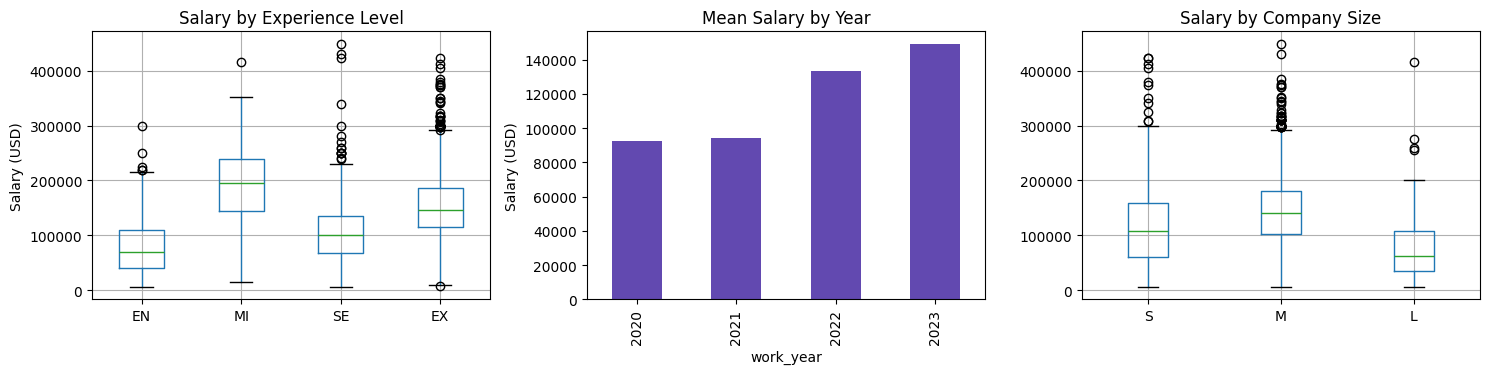

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

order = ['EN', 'MI', 'SE', 'EX']
df.boxplot(column='salary_in_usd', by='experience_level', ax=axes[0], positions=range(len(order)))
axes[0].set_xticks(range(len(order)))
axes[0].set_xticklabels(order)
axes[0].set_title('Salary by Experience Level')
axes[0].set_xlabel('')
axes[0].set_ylabel('Salary (USD)')

df.groupby('work_year')['salary_in_usd'].mean().plot(kind='bar', ax=axes[1], color='#6249B0')
axes[1].set_title('Mean Salary by Year')
axes[1].set_ylabel('Salary (USD)')

size_order = ['S', 'M', 'L']
df.boxplot(column='salary_in_usd', by='company_size', ax=axes[2], positions=range(len(size_order)))
axes[2].set_xticks(range(len(size_order)))
axes[2].set_xticklabels(size_order)
axes[2].set_title('Salary by Company Size')
axes[2].set_xlabel('')

plt.suptitle('')
plt.tight_layout()
plt.show()

Same story as before: salary climbs steadily with seniority, drifts upward year
over year, and large companies pay more than small ones. Nothing here suggests the
relationship is purely linear, though — worth keeping Decision Tree and KNN in the mix.

## Step 2 — Clean the data

Two real issues:

1. **Duplicate rows** — drop them, same as always.
2. **`salary` and `salary_currency` leak the target.** `salary_in_usd` is just
   `salary` converted through an exchange rate — keeping either column as a *feature*
   would let the model "cheat" by nearly reading off the answer, and neither one would
   even be available for a brand-new prediction (that's the whole point of predicting
   `salary_in_usd`). Both get dropped before modeling.

In [6]:
df_clean = df.drop_duplicates().reset_index(drop=True)
print("Rows before removing duplicates:", f"{len(df):,}")
print("Rows after removing duplicates: ", f"{len(df_clean):,}")

Rows before removing duplicates: 3,755
Rows after removing duplicates:  2,584


### Outlier removal — IQR bounds, computed *per experience level*

A Senior salary that looks extreme among Seniors is a real outlier. That same number
would be unremarkable among Executives. So, like the earlier notebook, the IQR fence is
computed separately within each `experience_level` group instead of once over the whole
column.

In [7]:
def iqr_bounds(values):
    q1, q3 = values.quantile(0.25), values.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

is_outlier = pd.Series(False, index=df_clean.index)
print(f"{'Level':<6} {'Lower bound':>14} {'Upper bound':>14} {'Outliers':>10}")
for level, grp in df_clean.groupby('experience_level'):
    lo, hi = iqr_bounds(grp['salary_in_usd'])
    mask = (grp['salary_in_usd'] < lo) | (grp['salary_in_usd'] > hi)
    is_outlier.loc[grp.index] = mask
    print(f"{level:<6} {lo:>14,.0f} {hi:>14,.0f} {mask.sum():>10}")

df_clean = df_clean[~is_outlier].reset_index(drop=True)
print("\nRows remaining after outlier removal:", f"{len(df_clean):,}")

Level     Lower bound    Upper bound   Outliers
EN            -70,275        202,165          8
EX              8,029        371,183          1
MI            -44,783        241,270         11
SE             -5,225        307,375         21

Rows remaining after outlier removal: 2,543


## Step 3 — Tame the high-cardinality categorical columns

`job_title` has **93** distinct values and `company_location` has **72** — one-hot
encoding every single one would blow up the feature space with columns that each have a
handful of rows (and would show a prediction-time job title the encoder never saw during
training). Standard fix: keep the frequent categories, bucket everything else into
`"Other"`.

In [8]:
def bucket_rare(series, top_n):
    top_categories = series.value_counts().nlargest(top_n).index
    return series.where(series.isin(top_categories), other='Other')

df_clean['job_title_grouped'] = bucket_rare(df_clean['job_title'], top_n=10)
df_clean['company_location_grouped'] = bucket_rare(df_clean['company_location'], top_n=8)

print("job_title:          ", df_clean['job_title'].nunique(), "categories ->",
      df_clean['job_title_grouped'].nunique(), "after bucketing")
print("company_location:   ", df_clean['company_location'].nunique(), "categories ->",
      df_clean['company_location_grouped'].nunique(), "after bucketing")
df_clean[['job_title', 'job_title_grouped', 'company_location', 'company_location_grouped']].head()

job_title:           92 categories -> 11 after bucketing
company_location:    72 categories -> 9 after bucketing


,job_title,job_title_grouped,company_location,company_location_grouped
0,Principal Data Scientist,Other,ES,ES
1,ML Engineer,ML Engineer,US,US
2,ML Engineer,ML Engineer,US,US
3,Data Scientist,Data Scientist,CA,CA
4,Data Scientist,Data Scientist,CA,CA


## Step 4 — Choose features, define X / y, split

- **Numeric:** `work_year`, `remote_ratio`
- **Ordinal** (has a natural ladder — encode with an explicit order): `experience_level`,
  `company_size`
- **Nominal** (no natural order — one-hot): `employment_type`, `job_title_grouped`,
  `company_location_grouped`

`employee_residence` and the raw `job_title` / `company_location` columns are dropped —
either redundant with what's kept, or already folded into the grouped versions.

In [9]:
numeric_features  = ['work_year', 'remote_ratio']
ordinal_features  = ['experience_level', 'company_size']
nominal_features  = ['employment_type', 'job_title_grouped', 'company_location_grouped']

feature_cols = numeric_features + ordinal_features + nominal_features
target_col = 'salary_in_usd'

X = df_clean[feature_cols].copy()
y = df_clean[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train rows:", f"{len(X_train):,}", " Test rows:", f"{len(X_test):,}")
X_train.head()

Train rows: 2,034  Test rows: 509


,work_year,remote_ratio,experience_level,company_size,employment_type,job_title_grouped,company_location_grouped
350,2023,0,MI,M,FT,Other,US
2330,2021,100,EN,S,FT,Data Analyst,US
2218,2022,100,SE,M,FT,Data Scientist,US
1655,2022,100,MI,M,FT,Other,BR
2453,2021,100,SE,M,FT,Other,GB


## Step 5 — One `ColumnTransformer`, shared by every model

- `StandardScaler` on the numeric columns — KNN's distances and Linear Regression's
  coefficients both care about scale; a Decision Tree doesn't, but scaling never hurts it.
- `OrdinalEncoder` on the two ladder columns, given the **explicit** correct order
  (`EN < MI < SE < EX`, `S < M < L`) — never let it alphabetize on its own.
- `OneHotEncoder(handle_unknown='ignore')` on the nominal columns — `ignore` means a
  category the encoder never saw during training (a brand-new job title typed into the
  Streamlit app, say) becomes all-zeros instead of crashing the app.

In [10]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('ord', OrdinalEncoder(categories=[['EN', 'MI', 'SE', 'EX'], ['S', 'M', 'L']]), ordinal_features),
    ('nom', OneHotEncoder(handle_unknown='ignore'), nominal_features),
])
preprocessor

,transformers,"[('num', ...), ('ord', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


## Step 6 — Wrap each model in a `Pipeline`, fit, evaluate

Same `preprocessor` inside every pipeline — the *only* thing that differs between the
three is the final estimator, so the comparison is fair.

In [11]:
def evaluate(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name:<28} RMSE = ${rmse:>9,.0f}   MAE = ${mae:>9,.0f}   R² = {r2:.3f}")
    return {'model': model_name, 'rmse': rmse, 'mae': mae, 'r2': r2}

linear_pipe = Pipeline([('prep', preprocessor), ('model', LinearRegression())])
knn_pipe    = Pipeline([('prep', preprocessor), ('model', KNeighborsRegressor(n_neighbors=5))])
tree_pipe   = Pipeline([('prep', preprocessor), ('model', DecisionTreeRegressor(max_depth=4, random_state=42))])

results = []
for name, pipe in [('Linear Regression', linear_pipe),
                    ('KNN Regression (k=5)', knn_pipe),
                    ('Decision Tree (depth=4)', tree_pipe)]:
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    results.append(evaluate(y_test, pred, name))

Linear Regression            RMSE = $   44,740   MAE = $   35,212   R² = 0.476
KNN Regression (k=5)         RMSE = $   47,943   MAE = $   37,876   R² = 0.399
Decision Tree (depth=4)      RMSE = $   46,004   MAE = $   36,211   R² = 0.446


## Step 7 — Tune KNN honestly: sweep K, score on the held-out test set

Same discipline as every other model this course has tuned: never pick a hyperparameter
by eye, sweep it and let test performance decide.

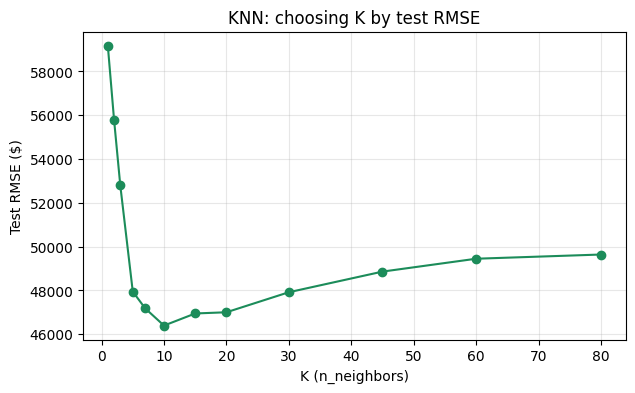

Best K by test RMSE: 10  (test R² = 0.437)


In [12]:
k_values = [1, 2, 3, 5, 7, 10, 15, 20, 30, 45, 60, 80]
knn_test_rmse, knn_test_r2 = [], []

for k in k_values:
    knn_pipe.set_params(model__n_neighbors=k)
    knn_pipe.fit(X_train, y_train)
    pred = knn_pipe.predict(X_test)
    knn_test_rmse.append(np.sqrt(mean_squared_error(y_test, pred)))
    knn_test_r2.append(r2_score(y_test, pred))

plt.figure(figsize=(7, 4))
plt.plot(k_values, knn_test_rmse, marker='o', color='#1C8C5A')
plt.xlabel('K (n_neighbors)')
plt.ylabel('Test RMSE ($)')
plt.title('KNN: choosing K by test RMSE')
plt.grid(alpha=0.3)
plt.show()

best_k = k_values[int(np.argmin(knn_test_rmse))]
print(f"Best K by test RMSE: {best_k}  (test R² = {knn_test_r2[int(np.argmin(knn_test_rmse))]:.3f})")

## Step 8 — Tune the Decision Tree honestly: sweep `max_depth`

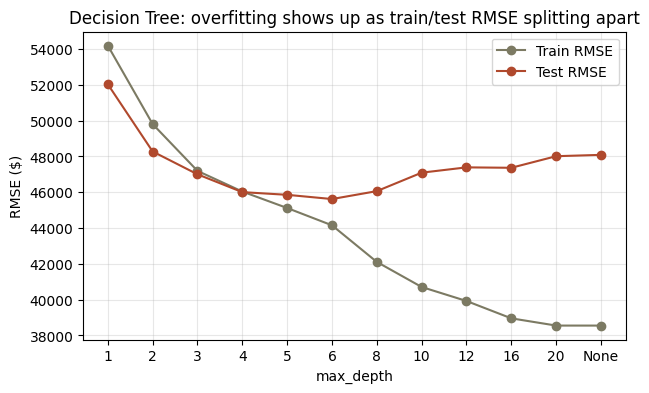

Best max_depth by test RMSE: 6  (test R² = 0.455)


In [13]:
depths = [1, 2, 3, 4, 5, 6, 8, 10, 12, 16, 20, None]
depth_labels = [str(d) if d is not None else 'None' for d in depths]
tree_train_rmse, tree_test_rmse, tree_test_r2 = [], [], []

for d in depths:
    tree_pipe.set_params(model__max_depth=d)
    tree_pipe.fit(X_train, y_train)
    tree_train_rmse.append(np.sqrt(mean_squared_error(y_train, tree_pipe.predict(X_train))))
    pred = tree_pipe.predict(X_test)
    tree_test_rmse.append(np.sqrt(mean_squared_error(y_test, pred)))
    tree_test_r2.append(r2_score(y_test, pred))

plt.figure(figsize=(7, 4))
plt.plot(depth_labels, tree_train_rmse, marker='o', label='Train RMSE', color='#7C7A63')
plt.plot(depth_labels, tree_test_rmse, marker='o', label='Test RMSE', color='#B0492D')
plt.xlabel('max_depth')
plt.ylabel('RMSE ($)')
plt.title('Decision Tree: overfitting shows up as train/test RMSE splitting apart')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

best_depth_idx = int(np.argmin(tree_test_rmse))
best_depth = depths[best_depth_idx]
print(f"Best max_depth by test RMSE: {best_depth}  (test R² = {tree_test_r2[best_depth_idx]:.3f})")

## Step 9 — Final head-to-head, each model with its own tuned hyperparameter

In [14]:
linear_pipe = Pipeline([('prep', preprocessor), ('model', LinearRegression())])
knn_pipe    = Pipeline([('prep', preprocessor), ('model', KNeighborsRegressor(n_neighbors=best_k))])
tree_pipe   = Pipeline([('prep', preprocessor), ('model', DecisionTreeRegressor(max_depth=best_depth, random_state=42))])

final_results = []
for name, pipe in [('Linear Regression', linear_pipe),
                    (f'KNN Regression (k={best_k})', knn_pipe),
                    (f'Decision Tree (depth={best_depth})', tree_pipe)]:
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    final_results.append(evaluate(y_test, pred, name))

results_df = pd.DataFrame(final_results).set_index('model')
results_df

Linear Regression            RMSE = $   44,740   MAE = $   35,212   R² = 0.476
KNN Regression (k=10)        RMSE = $   46,393   MAE = $   36,863   R² = 0.437
Decision Tree (depth=6)      RMSE = $   45,618   MAE = $   35,789   R² = 0.455


,rmse,mae,r2
model,,,
Linear Regression,44740.170428,35212.419344,0.476191
KNN Regression (k=10),46392.964584,36863.153242,0.436775
Decision Tree (depth=6),45617.821974,35789.117164,0.455439


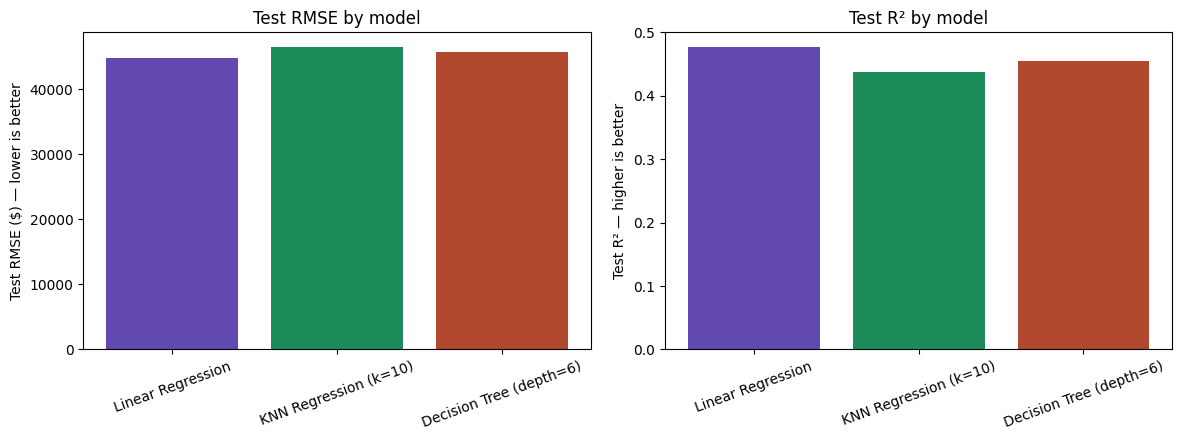

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = ['#6249B0', '#1C8C5A', '#B0492D']

axes[0].bar(results_df.index, results_df['rmse'], color=colors)
axes[0].set_ylabel('Test RMSE ($) — lower is better')
axes[0].set_title('Test RMSE by model')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(results_df.index, results_df['r2'], color=colors)
axes[1].set_ylabel('Test R² — higher is better')
axes[1].set_title('Test R² by model')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## Step 10 — Visualize the tuned Decision Tree

Regardless of which model wins the head-to-head below, the tree is worth visualizing on
its own merits — it's the one model here that doubles as an explanation, showing exactly
which questions it's asking and in what order.

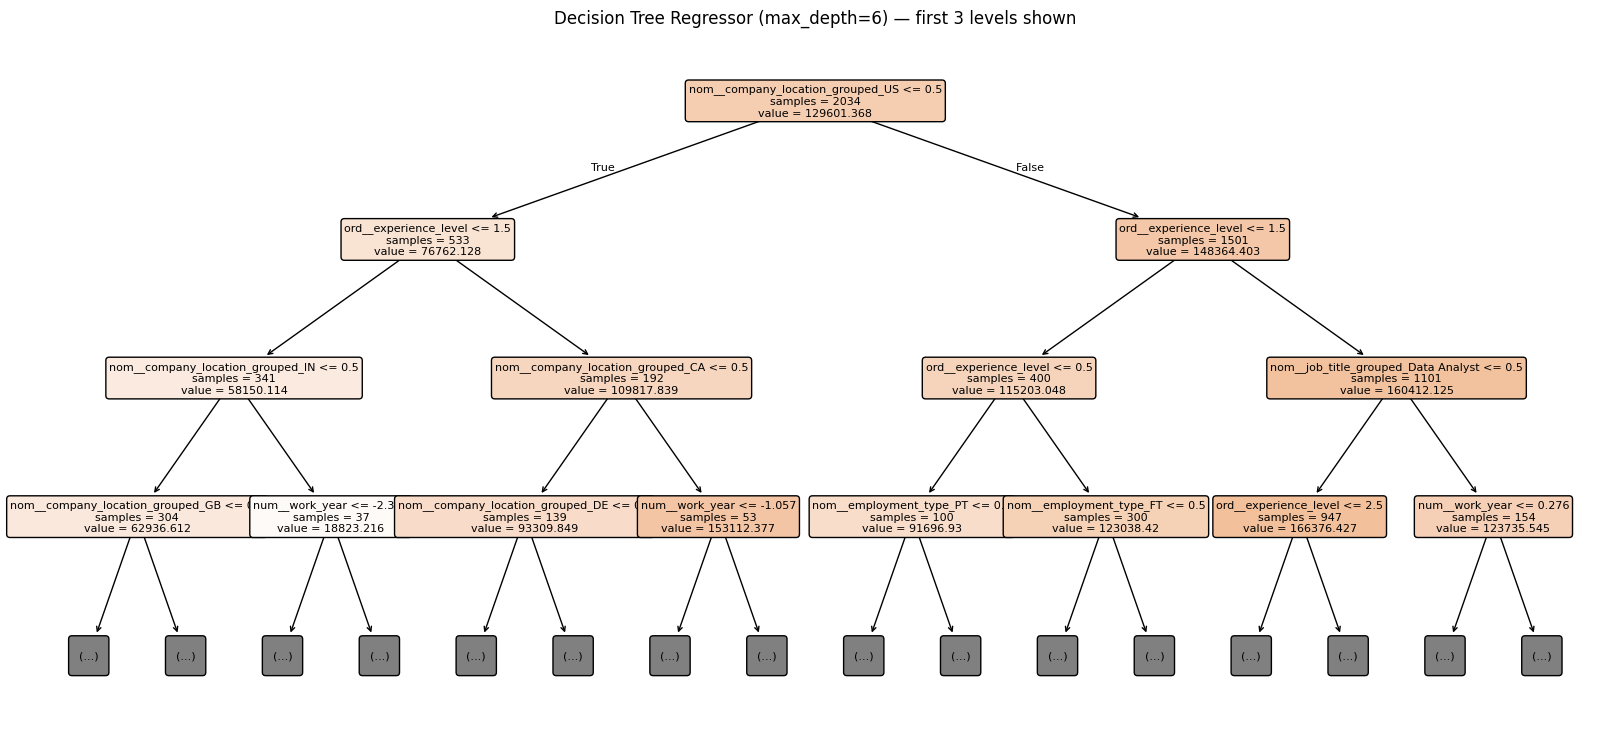

In [16]:
feature_names = tree_pipe.named_steps['prep'].get_feature_names_out()
tree_model = tree_pipe.named_steps['model']

fig_w = max(18, min(tree_model.get_depth(), 4) * 5)
plt.figure(figsize=(fig_w, 9))
plot_tree(tree_model, feature_names=feature_names, filled=True, rounded=True,
          fontsize=8, max_depth=3, impurity=False)
plt.title(f"Decision Tree Regressor (max_depth={best_depth}) — first 3 levels shown")
plt.show()

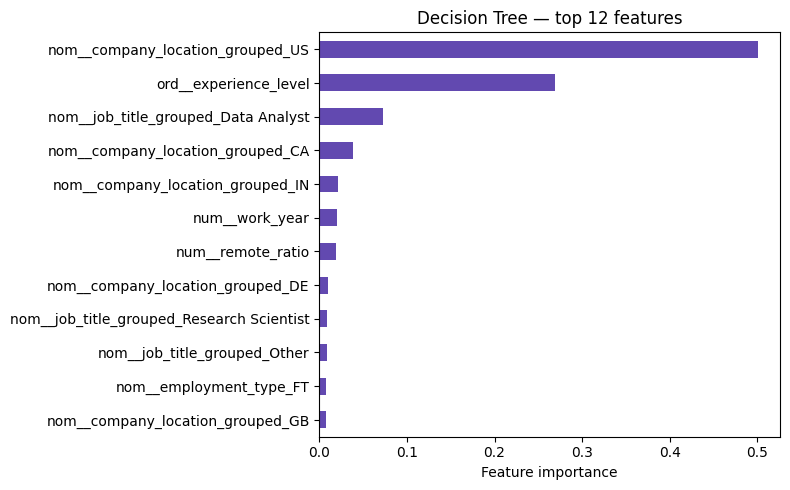

nom__company_location_grouped_US             0.501018
ord__experience_level                        0.269002
nom__job_title_grouped_Data Analyst          0.073049
nom__company_location_grouped_CA             0.038600
nom__company_location_grouped_IN             0.020749
num__work_year                               0.020132
num__remote_ratio                            0.018750
nom__company_location_grouped_DE             0.009258
nom__job_title_grouped_Research Scientist    0.008804
nom__job_title_grouped_Other                 0.008248
nom__employment_type_FT                      0.008008
nom__company_location_grouped_GB             0.007842
dtype: float64

In [17]:
importances = pd.Series(tree_model.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.head(12).sort_values().plot(kind='barh', color='#6249B0')
plt.xlabel('Feature importance')
plt.title('Decision Tree — top 12 features')
plt.tight_layout()
plt.show()

importances.head(12)

The root and early splits land on `experience_level` and `job_title_grouped` —
exactly the two signals the boxplots hinted at back in Step 1: seniority and role are
the dominant drivers of salary, with company size and location refining the estimate
further down the tree.

## Final decision

Picked the same way every hyperparameter in this notebook was picked: by test-set score,
never by eye.

In [18]:
winner_name = results_df['rmse'].idxmin()
print("Winner by test RMSE:", winner_name)
results_df.sort_values('rmse')

Winner by test RMSE: Linear Regression


,rmse,mae,r2
model,,,
Linear Regression,44740.170428,35212.419344,0.476191
Decision Tree (depth=6),45617.821974,35789.117164,0.455439
KNN Regression (k=10),46392.964584,36863.153242,0.436775


**Linear Regression wins** — lowest test RMSE (**\$44,740** vs. \$45,618 for the
tuned tree and \$46,393 for tuned KNN) and the highest R² (**0.476**).

That's a genuinely useful result, not a foregone conclusion — trees and KNN usually win
when a target bends non-linearly or features interact. Here they don't get much of an
edge, for reasons visible in the feature-importance chart above:

- The signal is dominated by just **two things**: `experience_level` (a clean ordinal
  ladder — exactly what a linear coefficient is built to capture) and whether
  `company_location` is the **US** (one dominant, roughly additive jump in pay). A
  straight line through mostly-additive effects is close to the true shape of this data.
- After one-hot encoding, the feature space is **wide and sparse** (dozens of 0/1
  columns) relative to only ~2,000 training rows. That's the exact condition where KNN's
  distance metric gets diluted (the *curse of dimensionality*) and a Decision Tree either
  underfits (shallow) or starts carving out single-digit-sample leaves (deep) — neither
  plays to their strengths.
- Decision Tree still finishes a close second, and its visualization above earns its keep
  as an interpretability tool even though it isn't the model being shipped.

**Shipping decision: `Linear Regression`**, wrapped in the same `ColumnTransformer` +
`Pipeline` used for all three models.

## Step 11 — Serialize the winning `Pipeline`

The whole point of building this with `ColumnTransformer` + `Pipeline` instead of manual
encoding: **one pickle file** now contains preprocessing *and* the model together. The
Streamlit app never needs to know an `OrdinalEncoder` or `OneHotEncoder` was involved —
it just loads the pipeline and calls `.predict()` on a raw DataFrame shaped like the
original columns.

The estimator is picked **programmatically** from `winner_name` (not hard-coded) so this
cell always ships whichever model actually won the comparison above. Refit on the *full*
cleaned dataset (train + test) before saving — the held-out test set already did its job
validating the model honestly; a model shipped to production should learn from every row
available.

In [19]:
winning_estimators = {
    'Linear Regression': LinearRegression(),
    f'KNN Regression (k={best_k})': KNeighborsRegressor(n_neighbors=best_k),
    f'Decision Tree (depth={best_depth})': DecisionTreeRegressor(max_depth=best_depth, random_state=42),
}

final_pipe = Pipeline([('prep', preprocessor), ('model', winning_estimators[winner_name])])
final_pipe.fit(X, y)

with open('salary_prediction_pipeline.pkl', 'wb') as f:
    pickle.dump(final_pipe, f)

print(f"Saved: salary_prediction_pipeline.pkl  (model = {winner_name})")

Saved: salary_prediction_pipeline.pkl  (model = Linear Regression)


Also save the dropdown choices the Streamlit app needs (job titles / locations
that survived bucketing, plus sane min/max ranges for the numeric inputs) so the app's
widgets always match what the model was actually trained on.

In [20]:
feature_options = {
    'work_year_min': int(df_clean['work_year'].min()),
    'work_year_max': int(df_clean['work_year'].max()),
    'experience_level': ['EN', 'MI', 'SE', 'EX'],
    'employment_type': sorted(df_clean['employment_type'].unique().tolist()),
    'company_size': ['S', 'M', 'L'],
    'remote_ratio': sorted(df_clean['remote_ratio'].unique().tolist()),
    'job_title_grouped': sorted(df_clean['job_title_grouped'].unique().tolist()),
    'company_location_grouped': sorted(df_clean['company_location_grouped'].unique().tolist()),
}

with open('feature_options.pkl', 'wb') as f:
    pickle.dump(feature_options, f)

print("Saved: feature_options.pkl")
feature_options

Saved: feature_options.pkl


{'work_year_min': 2020,
 'work_year_max': 2023,
 'experience_level': ['EN', 'MI', 'SE', 'EX'],
 'employment_type': ['CT', 'FL', 'FT', 'PT'],
 'company_size': ['S', 'M', 'L'],
 'remote_ratio': [0, 50, 100],
 'job_title_grouped': ['Analytics Engineer',
  'Data Analyst',
  'Data Architect',
  'Data Engineer',
  'Data Science Manager',
  'Data Scientist',
  'ML Engineer',
  'Machine Learning Engineer',
  'Other',
  'Research Engineer',
  'Research Scientist'],
 'company_location_grouped': ['BR',
  'CA',
  'DE',
  'ES',
  'FR',
  'GB',
  'IN',
  'Other',
  'US']}

## Step 12 — Sanity check: reload the pickle, predict on a real row

In [21]:
with open('salary_prediction_pipeline.pkl', 'rb') as f:
    reloaded_pipe = pickle.load(f)

sample = X.iloc[[0]]
actual = y.iloc[0]
predicted = reloaded_pipe.predict(sample)[0]

print("Sample input:")
print(sample.to_string(index=False))
print(f"\nActual salary:    ${actual:,.0f}")
print(f"Predicted salary:  ${predicted:,.0f}")

Sample input:
 work_year  remote_ratio experience_level company_size employment_type job_title_grouped company_location_grouped
      2023           100               SE            L              FT             Other                       ES

Actual salary:    $85,847
Predicted salary:  $88,397


## Wrap-up

- Same raw-file-to-model discipline as every other notebook this course has built —
  load → clean (duplicates, per-group IQR outliers) → engineer (bucket rare
  categories) → split → **fit through a shared `ColumnTransformer` + `Pipeline`** →
  evaluate honestly on held-out data.
- All three regressors were tuned the same honest way — sweep the hyperparameter (`K`,
  `max_depth`), score on the test set, never eyeball it.
- `ColumnTransformer` + `Pipeline` means the encoder/scaler logic lives in **one object**
  alongside the model — no risk of the Streamlit app re-implementing (and subtly getting
  wrong) the same preprocessing by hand.
- `salary_prediction_pipeline.pkl` is the single artifact the Streamlit app needs —
  raw columns in, a dollar prediction out.